<a href="https://colab.research.google.com/github/harshdharmik29/jjojjojojoj/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) on Retail Sales Data



## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on retail sales data to identify sales trends, customer behavior, and business insights that can help improve business decision-making.

## Data Loading

In this section, the retail sales dataset is loaded using Pandas and the first few records are examined.

## Data Understanding

The dataset contains information about transactions, customers, product categories, quantity purchased, and sales amount. Understanding the dataset structure is the first step before analysis.

In [ ]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")

print(df.shape)
print(df.columns)
df.head()

(1000, 9)
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Data Cleaning

The dataset was checked for missing values and duplicate records to ensure data quality before performing analysis.

Data Quality Check

In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0


## Descriptive Statistics

Basic statistical measures were calculated to understand the distribution of sales data.

Observation:
- Average transaction value was ₹456.
- Median transaction value was ₹135.
- The difference between mean and median suggests the presence of high-value transactions.
- Standard deviation was high, indicating significant variation in sales amounts.

In [ ]:
print("Mean:", df["Total Amount"].mean())

print("Median:", df["Total Amount"].median())

print("Mode:")
print(df["Total Amount"].mode())

print("Standard Deviation:", df["Total Amount"].std())

Mean: 456.0
Median: 135.0
Mode:
0    50
Name: Total Amount, dtype: int64
Standard Deviation: 559.997631555123


Business Overview

In [ ]:
print("Total Revenue:", df["Total Amount"].sum())

print("Highest Sale:", df["Total Amount"].max())

print("Lowest Sale:", df["Total Amount"].min())

print("Total Transactions:", len(df))

Total Revenue: 456000
Highest Sale: 2000
Lowest Sale: 25
Total Transactions: 1000


## Product Category Analysis

Revenue generated by each product category was analyzed to identify the best-performing category.

In [ ]:
print(df.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [ ]:
df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


Observation:
- Electronics generated the highest revenue.
- Clothing generated nearly the same revenue as Electronics.
- Beauty generated the lowest revenue among all categories.

Graph

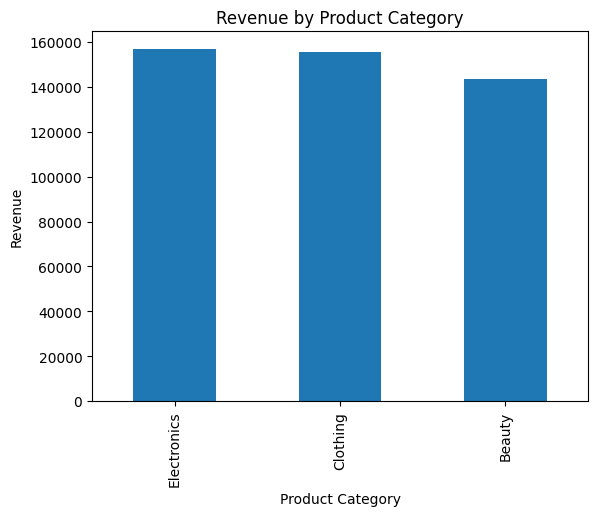

In [ ]:
import matplotlib.pyplot as plt

category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

## Gender Analysis

Customer purchasing behavior was analyzed based on gender.

In [ ]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


Observation:
- Female customers generated slightly higher revenue than male customers.
- The difference was small, indicating balanced purchasing behavior.

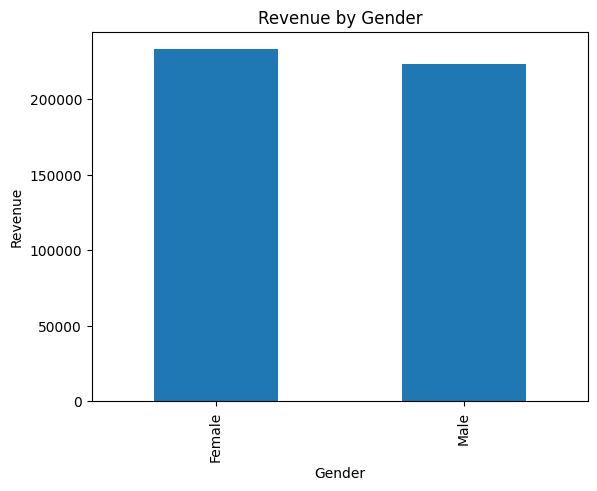

In [ ]:
gender_sales.plot(kind="bar")

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")
plt.show()

## Age Analysis

Customer age distribution was analyzed to understand the target customer base.

In [ ]:
df["Age"].describe()

,Age
count,1000.00000
mean,41.39200
std,13.68143
min,18.00000
25%,29.00000
50%,42.00000
75%,53.00000
max,64.00000


Observation:
- Average customer age was approximately 41 years.
- Customers ranged from 18 to 64 years old.
- The business serves a wide range of age groups.

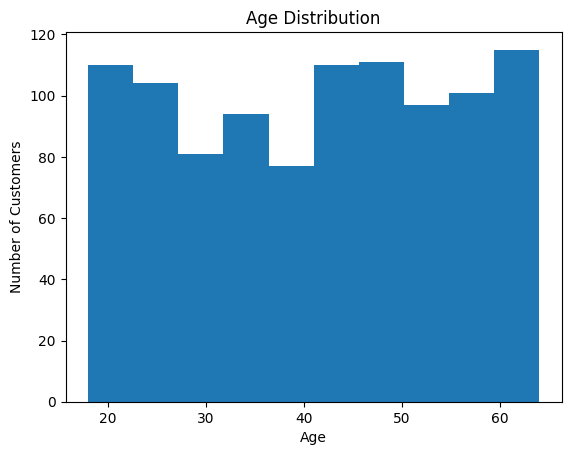

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

Sales Trend Analysis (Time Series)

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
print(df["Date"].min())      #this is only 1 year sale so find monthly tread
print(df["Date"].max())

2023-01-01 00:00:00
2024-01-01 00:00:00


## Monthly Sales Trend Analysis

Monthly revenue was analyzed to identify seasonal sales patterns and trends.

In [ ]:
monthly_sales = df.groupby(df["Date"].dt.month)["Total Amount"].sum()

print(monthly_sales)

Date
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64


Observation:
- May recorded the highest sales.
- September recorded the lowest sales.
- Sales recovered significantly during the final quarter of the year.

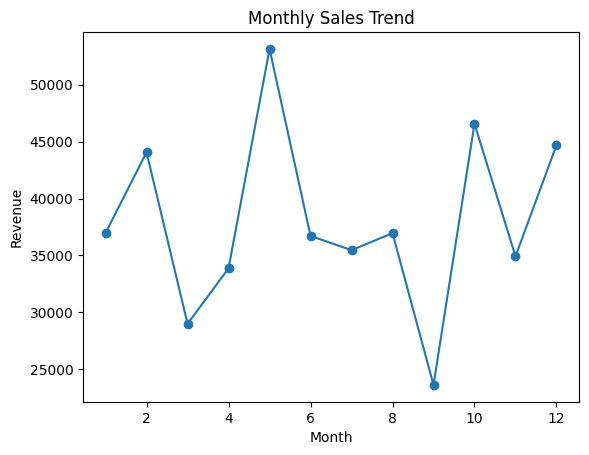

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## Quantity Analysis

The total quantity sold for each product category was analyzed.

Observation:
- Clothing had the highest number of units sold.
- Electronics generated higher revenue despite lower quantity sold.
- This indicates that Electronics products have higher average prices.

In [ ]:
quantity_by_category = df.groupby("Product Category")["Quantity"].sum()

print(quantity_by_category)

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64


## Correlation Analysis

A correlation heatmap was used to understand relationships between numerical variables.

Observation:
- Price per Unit showed a strong positive correlation with Total Amount.
- Quantity had a moderate positive correlation with Total Amount.
- Age showed very little correlation with sales performance.

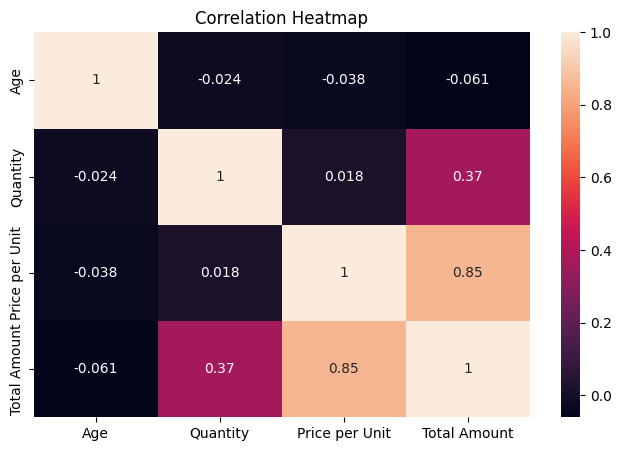

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Age","Quantity","Price per Unit","Total Amount"]].corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

## Key Insights

1. Total revenue generated was ₹456,000.
2. Electronics was the highest revenue-generating category.
3. Clothing recorded the highest sales volume.
4. Female customers contributed slightly more revenue.
5. Average customer age was 41 years.
6. Sales peaked in May and declined in September.
7. Product pricing had the strongest impact on revenue generation.

## Recommendations

1. Maintain sufficient inventory for Electronics and Clothing products.
2. Improve promotional strategies for Beauty products.
3. Investigate factors causing low sales in September.
4. Focus on pricing strategies to maximize revenue.
5. Continue targeting both male and female customer segments.

## Conclusion

This project successfully analyzed retail sales data and identified important business insights. The findings highlighted sales trends, customer behavior, product performance, and key revenue drivers. These insights can help businesses make informed decisions and improve overall performance.